# Predictive Analytics Final Project Tennis Match Predictions

## Predictive Analytics BDM500

## By: Andrey Kudritskiy

## Student ID: 123300196



The goal of this report/notebook is to explore how predictive analytics can be applied to tennis match data, and predicting who would win between two players.

## Importing, cleaning and prepping data

In [ ]:
import pandas as pd
import os
import re
import numpy as np
from collections import deque
import random
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
!git clone https://github.com/JeffSackmann/tennis_atp
#run above if the repo has yet to be cloned.

if os.path.exists('tennis_atp'):
    print("Repository cloned successfully.")
else:
    print("Repository cloning failed.")

Cloning into 'tennis_atp'...
remote: Enumerating objects: 4193, done.
remote: Total 4193 (delta 0), reused 0 (delta 0), pack-reused 4193 (from 1)
Receiving objects: 100% (4193/4193), 339.73 MiB | 21.56 MiB/s, done.
Resolving deltas: 100% (3289/3289), done.
Updating files: 100% (180/180), done.
Repository cloned successfully.


In [ ]:
repo_path = 'tennis_atp'
target_files = re.compile(r"^atp_matches_\d{4}\.csv$")#I'm only intrested singles atp matches...

if os.path.exists(repo_path):
    #print(f"Listing ATP match CSVs in '{repo_path}':")

    csv_files = [
        f for f in os.listdir(repo_path)
        if target_files.match(f)]

    if csv_files:
        for f in csv_files:
            pass
            #print(f) was used intially to check file names, now it's just unwanted clutter
    else:
        print("No matching atp_matches_YYYY.csv files found.")
else:
    print(f"Repository directory '{repo_path}' not found. Please ensure it was cloned successfully.")


In [ ]:
tennis_matches = pd.DataFrame()
tennis_players = pd.read_csv(os.path.join(repo_path,"atp_players.csv"))#should be useful for mapping player id to name & info

for file_name in csv_files:
    file_path = os.path.join(repo_path, file_name)
    df = pd.read_csv(file_path)
    tennis_matches = pd.concat([tennis_matches, df], ignore_index=True)

/tmp/ipython-input-1393961138.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  tennis_players = pd.read_csv(os.path.join(repo_path,"atp_players.csv"))#should be useful for mapping player id to name & info


In [ ]:
tennis_matches

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2009-1536,Madrid Masters,Clay,56.0,M,20090510,1,103781,NaN,NaN,...,51.0,35.0,26.0,15.0,3.0,6.0,27.0,1735.0,28.0,1724.0
1,2009-1536,Madrid Masters,Clay,56.0,M,20090510,2,104259,NaN,NaN,...,36.0,29.0,13.0,9.0,7.0,9.0,35.0,1510.0,34.0,1515.0
2,2009-1536,Madrid Masters,Clay,56.0,M,20090510,3,105227,13.0,NaN,...,45.0,26.0,21.0,13.0,5.0,10.0,14.0,2635.0,90.0,835.0
3,2009-1536,Madrid Masters,Clay,56.0,M,20090510,4,103970,12.0,NaN,...,26.0,14.0,18.0,8.0,7.0,12.0,13.0,2645.0,108.0,734.0
4,2009-1536,Madrid Masters,Clay,56.0,M,20090510,5,104338,NaN,WC,...,44.0,31.0,25.0,11.0,12.0,14.0,47.0,1240.0,32.0,1620.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194991,1980-D026,Davis Cup EUR F: ROU vs TCH,Clay,4.0,D,19800711,5,100730,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.0,NaN
194992,1980-D027,Davis Cup EUR PR: YUG vs ROU,Hard,4.0,D,19800204,1,100119,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,61.0,NaN,NaN,NaN
194993,1980-D027,Davis Cup EUR PR: YUG vs ROU,Hard,4.0,D,19800204,2,100730,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
194994,1980-D027,Davis Cup EUR PR: YUG vs ROU,Hard,4.0,D,19800204,4,100730,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
tennis_matches.shape

(194996, 49)

In [ ]:
tennis_matches.dtypes

,0
tourney_id,object
tourney_name,object
surface,object
draw_size,float64
tourney_level,object
tourney_date,int64
match_num,int64
winner_id,int64
winner_seed,float64
winner_entry,object


## Dataset Description

The tennis_atp dataset is a collection of historical data about men’s professional tennis.

* Players info: Each player’s ID, name, handedness (left/right), height, date of birth, and country.

* Rankings: Player rankings over time with points.

* Match results: Every match shows who played, who won, the score, and tournament info.

* Match stats (when available): Things like aces, first serve in, break points won, etc.

* It mostly covers the main ATP tour from the 1970s to today, with more detailed stats from around 1991. People use it to analyze player performance, predict match outcomes, and study trends in men’s tennis.

### What each column/variable means

https://github.com/JeffSackmann/tennis_atp/blob/master/matches_data_dictionary.txt?utm_source=chatgpt.com

<u>Tournament Data</u>

* tourney_id – Unique identifier for each tournament.
* tourney_name – Name of the tournament (e.g., Wimbledon, US Open).
* surface – Court surface type (e.g., Hard, Clay, Grass).
* draw_size – Number of players in the tournament draw.
* tourney_level – Level of the tournament (e.g., G for Grand Slam, M for Masters 1000).
* tourney_date – Start date of the tournament in YYYYMMDD format.

<u>Match meta-data</u>

* match_num – Match number within the tournament.
* round – Tournament round (e.g., R32, Quarterfinal, Final).
* best_of – Maximum number of sets (3 or 5).
* minutes – Duration of the match in minutes.
* score – Final match score as text.

<u>Winner Info</u>
* winner_id – Unique player ID of the match winner.
* winner_seed – Seed number assigned to the winner (if seeded).
* winner_entry – How the winner entered the draw (e.g., WC for wild card, Q for qualifier).
* winner_name – Full name of the winning player.
* winner_hand – Playing hand (R for right-handed, L for left-handed).
* winner_ht – Height of the winner in centimeters.
* winner_ioc – Winner’s country code.
* winner_age – Winner’s age at the time of the match.
* winner_rank – ATP ranking of the winner at the time of the match.
* winner_rank_points – Ranking points held by the winner.

<u>Loser Info</u>
* loser_id – Unique player ID of the match loser.
* loser_seed – Seed number assigned to the loser (if seeded).
* loser_entry – How the loser entered the draw.
* loser_name – Full name of the losing player.
* loser_hand – Playing hand of the loser.
* loser_ht – Height of the loser.
* loser_ioc – Loser’s country code.
* loser_age – Loser’s age at match time.
* loser_rank – ATP ranking of the loser at the time of the match.
* loser_rank_points – Ranking points held by the loser.

<u>Winner Match Stats</u>
* w_ace – Number of aces hit by the winner.
* w_df – Number of double faults by the winner.
* w_svpt – Total serve points attempted by the winner.
* w_1stIn – Number of first serves that landed in.
* w_1stWon – Points won on first serve.
* w_2ndWon – Points won on second serve.
* w_SvGms – Number of service games played by the winner.
* w_bpSaved – Break points saved by the winner.
* w_bpFaced – Break points the winner faced.

<u>Lose Match stats</u>
* l_ace – Number of aces by the loser.
* l_df – Number of double faults by the loser.
* l_svpt – Total serve points attempted by the loser.
* l_1stIn – First serves that landed in.
* l_1stWon – Points won on first serve by the loser.
* l_2ndWon – Points won on second serve.
* l_SvGms – Number of service games by the loser.
* l_bpSaved – Break points saved by the loser.
* l_bpFaced – Break points the loser faced.


### Getting a feel for possible values in each column

In [ ]:
for col in tennis_matches.columns:
    print('Column:',col, set(tennis_matches[col][190000:190010]))

Column: tourney_id {'1983-540'}
Column: tourney_name {'Wimbledon'}
Column: surface {'Grass'}
Column: draw_size {128.0}
Column: tourney_level {'G'}
Column: tourney_date {19830620}
Column: match_num {192, 193, 194, 195, 196, 197, 198, 199, 190, 191}
Column: winner_id {100516, 100936, 100253, 100272, 100657, 100530, 100567, 100923, 101084, 100765}
Column: winner_seed {nan, nan, nan, nan, nan, nan, nan, nan, nan, nan}
Column: winner_entry {nan, 'WC', 'Q'}
Column: winner_name {'Andrew Jarrett', 'Mike Leach', 'Henri Leconte', 'Wally Masur', 'Sandy Mayer', 'Rodney Harmon', 'Chip Hooper', 'Jakob Hlasek', 'Tom Gullikson', 'Andreas Maurer'}
Column: winner_hand {'L', 'R'}
Column: winner_ht {198.0, 175.0, 178.0, nan, 180.0, 185.0, 188.0}
Column: winner_ioc {'AUS', 'GBR', 'SUI', 'GER', 'FRA', 'USA'}
Column: winner_age {18.6, 19.9, 20.1, 21.8, 23.2, 24.6, 25.2, 31.7, 25.4, 31.2}
Column: loser_id {100448, 100449, 100673, 100855, 100359, 100281, 100565, 100759, 100537, 100667}
Column: loser_seed {nan,

### Setting correct datetype for date column

In [ ]:
tennis_matches['tourney_date'] = pd.to_datetime(tennis_matches['tourney_date'], format="%Y%m%d")
tennis_matches.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2009-1536,Madrid Masters,Clay,56.0,M,2009-05-10,1,103781,NaN,NaN,...,51.0,35.0,26.0,15.0,3.0,6.0,27.0,1735.0,28.0,1724.0
1,2009-1536,Madrid Masters,Clay,56.0,M,2009-05-10,2,104259,NaN,NaN,...,36.0,29.0,13.0,9.0,7.0,9.0,35.0,1510.0,34.0,1515.0
2,2009-1536,Madrid Masters,Clay,56.0,M,2009-05-10,3,105227,13.0,NaN,...,45.0,26.0,21.0,13.0,5.0,10.0,14.0,2635.0,90.0,835.0
3,2009-1536,Madrid Masters,Clay,56.0,M,2009-05-10,4,103970,12.0,NaN,...,26.0,14.0,18.0,8.0,7.0,12.0,13.0,2645.0,108.0,734.0
4,2009-1536,Madrid Masters,Clay,56.0,M,2009-05-10,5,104338,NaN,WC,...,44.0,31.0,25.0,11.0,12.0,14.0,47.0,1240.0,32.0,1620.0


### Reducing df size through better dtypes and downcasting

pandas read every column in with a lot of wasted memory/overhead. all floats are float64, ints are int64. we are often storing values in certain columns like draw size which won't ever go 128, like that of column "draw size", but it's being stored as float 64 instead of an int. (arguably draw size is expected to always be an intiger anyways. the least we could do is manually tune the assigned byte sizes to our columns that go overkill with data allocation. This should have a substantial impact on the size of our df (therfore impacting operations/model training speeds later).

In [ ]:
print(max(tennis_matches.draw_size))

128.0


before:

In [ ]:
tennis_matches.memory_usage(deep=True).sum()/1_048_576 #Result in MB (megabytes)

np.float64(187.6930694580078)

In [ ]:
def cols_to_category(*column_names):
    for col in column_names:
        tennis_matches[col] = tennis_matches[col].astype("category")
    return "Finished changing to categorical dtype"

def downcasting_ints(*column_names):
    for col in column_names:
        tennis_matches[col] = pd.to_numeric(tennis_matches[col], downcast="integer")
    return "Finished downcasting all passed integer columns"

def downcasting_floats(*column_names):
    for col in column_names:
        tennis_matches[col] = pd.to_numeric(tennis_matches[col], downcast="float")
    return "Finished downcasting all passed float columns"

categorizable_features = [
    "tourney_name","surface","draw_size",
    "tourney_level","winner_seed","winner_entry",
    "winner_name","winner_hand","winner_ioc",
    "winner_id","loser_seed","loser_entry",
    "loser_name","loser_hand","loser_ioc","loser_id"]

downcastable_ints = tennis_matches.select_dtypes(include=["int", "int32", "int64"]).columns
downcastable_floats = tennis_matches.select_dtypes(include=["float"]).columns

In [ ]:
cols_to_category(*categorizable_features)
downcasting_ints(*downcastable_ints)
downcasting_floats(*downcastable_floats)

'Finished downcasting all passed float columns'

after:

In [ ]:
tennis_matches.memory_usage(deep=True).sum()/1_048_576 #Result in MB (megabytes)

np.float64(61.68815326690674)

In [ ]:
tennis_matches.head(3)

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2009-1536,Madrid Masters,Clay,56.0,M,2009-05-10,1,103781,NaN,NaN,...,51.0,35.0,26.0,15.0,3.0,6.0,27.0,1735.0,28.0,1724.0
1,2009-1536,Madrid Masters,Clay,56.0,M,2009-05-10,2,104259,NaN,NaN,...,36.0,29.0,13.0,9.0,7.0,9.0,35.0,1510.0,34.0,1515.0
2,2009-1536,Madrid Masters,Clay,56.0,M,2009-05-10,3,105227,13.0,NaN,...,45.0,26.0,21.0,13.0,5.0,10.0,14.0,2635.0,90.0,835.0


Doing this has saved us/reduced the size of our data by 100+MB (more than half)

In [ ]:
tennis_matches.dtypes #new dtypes

,0
tourney_id,object
tourney_name,category
surface,category
draw_size,float32
tourney_level,category
tourney_date,datetime64[ns]
match_num,int16
winner_id,int32
winner_seed,float32
winner_entry,category


In [ ]:
tennis_players.head()

,player_id,name_first,name_last,hand,dob,ioc,height,wikidata_id
0,100001,Gardnar,Mulloy,R,19131122.0,USA,185.0,Q54544
1,100002,Pancho,Segura,R,19210620.0,ECU,168.0,Q54581
2,100003,Frank,Sedgman,R,19271002.0,AUS,180.0,Q962049
3,100004,Giuseppe,Merlo,R,19271011.0,ITA,NaN,Q1258752
4,100005,Richard,Gonzalez,R,19280509.0,USA,188.0,Q53554


In [ ]:
print(f"There are {len(tennis_players)} players in the dataset.")

There are 65989 players in the dataset.


### Dealing with missing values
We have a ton of missing values, the challenge or problem is: not all missing values are created equal... alot of the missing values in the matches dataframe are not exactly falgged by isna() as True for the simple reason that data was never collected and merits a naive imputation blindly. Some of these missing values have meaning for instance here are some differing examples:

* Surface missing is just that, a missing point of data to describe the surface played on.
* Winner and loser hand columns feature both "Uknown" and "nan" categories, implying some were simply not recorded while others are undecided...
* A missing value in a the seed label however, (winner or loser seed) describes what seed a player got (best players get 1, followed by 2,3,4 until the worst players get the worst seeds.) Na None implies that the player was not seeded (did not get a specific assigned position in the bracket). This practice is done to make tournaments more entertaining, ensuring that strong players meet later on in the tournament (1 and 2 seeds start on opposite ends, like 3 and 4)... this ensures that the best players don't play each other all in the 1/128 or 1/64 or 1/32 rounds, this allows for better engagment from audiences as tension builds to watch the best players meet in the semi-finals/finals.
* A label like winner or loser entry does not mean that we never collected how they entered, it means that they entered in a way that was different from what the dataset recrods. for instance: Q is for qualify (players earned there way into the tourney, no by rank), wild cards (who might have returned after a long hiatus of play (due to injury or "un-retiring")) a few more are LL (lucky loser)--> lost qulifier but a spot oppened up. SE = Special exempt because they cannot play or finish qualifiers because they are busy. the list goes on... point is we don't want to replace this value with just a mode blindly. they fact that it's missing is telling us that it's neither of the other options (or was never recorded). regardless we could capture this data as a category like "not specified" and the models we use could potentially use this as a context clue towrads their performance.

The list goes on for almost any of our data labels that are categorical in nature and are missing values. Unfortunately the documentaiton/description of the dataset is not so detailed to explain many of the missing values

As for numerical labels like loser and winner age or height these could be imputed and derived from means, medians of the sample of our tennis players. but that is reducing accuracy and distorts the true values from our model ever so slightly. The problem is with 49 labels and so many missing values across them. there is potential to really throw off our models with each assumption we make.

fortunately for us, we don't need to worry too much about missing data because the model we are using to predict outcomes can handle missing data inately. but first we need to introduce it...

In [ ]:
tennis_matches.isna().sum()

,0
tourney_id,0
tourney_name,0
surface,2990
draw_size,835
tourney_level,0
tourney_date,0
match_num,0
winner_id,0
winner_seed,122776
winner_entry,177776


## Introducing XGBoost

* Decision trees vs forrests vs XGboost

A decision tree is a model that sets conditions like (greater than or less than threshholds) to split data recursevily (given certain parameters like tree depth and minimum leaf size/ minimum split size ect...) until a final classifiation or value is returned (depends or classification or regressor tree).

A random forrest model is an ensemble model that uses many decision trees together each with different branches/choice options to arrive at a given classification/value (classification/regressor trees respectively). The classifiers forrests opperate on majority vote, while the regressors use a mean/average of all the results to try and converge the predicted value to the true value. many trees can be generated (even on smaller datasets) by using boostrapping to reduce overfitting that a single tree model would introduce.

XGboost on the other hand uses the same ensemble approach of decision trees as a random forrest, but instead of making all the trees indipendently through bagging, they are instead made one by one sequentially constantly improving and adding their output to a final prediction over itterations at each step the most recent tree evaluates the previous residual (calculated by showing the model the target value in the training set and comparing to the prediction generated by the individual tree which was shown training set data). At each tree itteration, the prediction is multiplied by a learning rate "n" which is a number that shrinks the final result (can be over 1, but idk why you'd want to magnify your results)... this means that any tree's prediction is shrunk by n (could be 1/2 could be 1/1000). Smaller values of n cause the previous predictions to shrink slower meaning more trees are required to "converge" onto the true target y (in our case predicting wether player 1 or 2 wins.) while larger n's shrink values less which can lead to overfitting (because less trees are required to meet a threshold to

* A more intuitive look at XBoost (equation):
where:
* $\hat{y}_{final}$ is the final output of the model
* $\hat{y}_0$ is an original prediction we start off with, using some basic model/prediction/assumption.
* $T_i$ is a given tree i
* $n$ is the number we shrink each model predictions by
* x is the input data we feed to our models

$$\hat{y}_{final} = \hat{y}_0 + n \ T_1(x) +  n \ T_2 (x) ... + n \ T_i(x)$$

In the case of our dataset and goal (predicting tennis match outcomes...) it would sound/look a little something like this...
using a logit function we can start a chance for y_0 of 50% so logit(50%) = 0

* we then create a new tree based on our model's performance on a training set, then we get a new % chance (let's say 75%) for player 1 to win (by extension loose 1-p=lose %)...

* the model adds the logit(75%) = 1.0986 which is then scaled by n (let's say it's 0.01) so 1.0986*0.01 = 0.0010986

* 0.0010986 is then added to the original logit(50%)=0 based prediction. giving us 0.0010986

* the logit function will then add or subtract to our final model scaled repeatedly...

* this continues over i many iterations until we get the summation of our logit values, covert them back ot a percentage and we can then determine our verdict on who will win (something like 35% for player 1 (meaning expected loss).

## Why not imputing is a good approach for XGboost model

XBoost, unlike decision tree classifiers/regressors (by extension forrests) which cannot handle missing data (at least in sklearn library and that I am aware of). XGboost knows what to do and can optimize for the presence of missing data. Whenever an XGboost model sees a missing value, it assigns has a default direction behavior (go right in the tree always) for instance when the model sees the winner_rank label is missing it may be able to "learn" how to react to the missigness of such a label and what it entails. It is these optimizations over iterations of trees that can be trusted, more than the assumptions made during imputation at the very least.

Antoher way to phrase this is intuitively as a person one might interpret that missing a rank is a new palyer/rookie playing in the atp (usually some one young, new/inexperienced) and can assume they'd lose to some one of the same age/height/other factors with lots of experience demonstrated through high game counts/atp rank. The XGboost trees may try to model such inexperience through the branches that follow a missing data node on the tree.

### One more thing about XGboost

XGboost stands for "Extreme Gradient Boosting", this refers to it's use of gradient descent in optimizing the model's tree iterations. To put it simply it looks to find the "steepest"(largest rate of change/derivative) in a target direction/destination (in our case the smallest loss/residual/error in our model. This is accomplished by using different parameter combinations.

a simplified example for our context is looking for what we are aiming to do. is...
* guessing what is the optimal place to split ages on a branch in our model... gradient descent would try age = [ages <20, >25, <30] it would then pick the change in parameters that most significantly made the loss decrease.

* This seems simple when only considering 1 dimension, however we have 49 labels to deal with (atm, may change later). that's 49 dimensions.

* most intuitively understood with the example of finding the base of a mountain in 3d space and moving 100m at a time, then 60m, then 15, then 4,3,2,ect...

* there is a large risk of "local minimums" we may run into. especially if one of our features dominates the others...

I could continue looking at many different columns/labels in our dataset, but there's 49 of them, which would be overkill

## Data leakage addresed through featured engineering

To the observant, it's rather plain to see a huge problem in our data we have in it's raw state, half our labels either directly or inderctly decalre who won the game (our target value). If we fed our data to a model right now, it would be very problematic. an example would be player handedness winning when players have different hands. an association can be built between the model and who's hand is who's. A model would be able to pick up that any given player "A"  that is right handed and any given player B who is not right handed, so left handed and therefore opposite to "A" will have a match determined by who's dominant hand appears in the winner_hand column/label.any of the serving statistics also reveal what happened during a match, information no model or person would have before a match of tennis starts

a better way to feed data to our model would be through something like generating features such as:

* games won in row --> might be able to help diffrentiate upsets from consistent players
* total games played --> helps identify rookies (high volatility/uncertainty for matchup)
* win rate --> in the long run, great players will have a higher metric
* days since last recorded atp game played --> potentially capture injuries, suspensions or canceled retirements
* player Elo before the match --> really great for prediction/skill comparison. if it works for chess, video game matchmaking, why not work for tennis?
* etc...

### Using a "Lag" approach
Our current dataset/dataframe displays match info **AFTER** a game is done we want the state of player **BEFORE** a game is played. Our goal is to create an entirely new datset with features. although not a true lag like in time sreies analysis the effect is the same, we are delaying the data for any match to before it was played to avoid data leakage in our model.

<u>***note: I could not make enough time to implement all of these, I'll keep them here as they are still worth mentioning, but I won't be making all these features***</u>

In the end I want to have a dataframe that can be fed directly into a model. the features I plan to implement are in no particular order:
* player ID (name not needed can just map player ID to name later.
* dom_hand - a players dominant hand (not-engineered)
* age_at_match - how old a tennis player is when they played/ are about to play (not-engineered)
* country (not-engineered)
* height (not-engineered)
* pref_surf the surface the player plays at their best on (think rafael nadal on clay courts --> 90.5% win rate)
* time_spent - ... in atp league helps seperate those who are same age, but one started late
* elo rating
* surface elo
* recent performance - winrate past 5,10,20 games capture "hotstreaks"/players in their prime
* game_diff - measures how much won or lost by (0 implies close, 12 implies crushing opponent)
* game_diff_10 - measures game diff across the past 10 games/10- are you consistently crushing opponents?
* head2head_rate - measures winrate between two players
* current_round -  round of given tournament
* f_serve_10 - past 10 games number of first serves made - can capture nets, total points played in game
* s_serve_10 - can capture failed first serves
* f_serve_all - first serve all time count/games played
* s_serve_all - second serve all time count/games played
* aces_10  - aces count / 10 games
* ace_all - gall time
* doublef_10 - double faults past 10
* doublef_all - all time/games played
* all past 10 stats could also have their own most recent...

there are plenty of more relevant features to generate, but for now let's focus on the ones listed above

Setting df into chronological order

In [ ]:
tennis_matches = tennis_matches.sort_values(
    by=['tourney_date', 'match_num'],
    ascending=[True, True])

display(tennis_matches.head(3))
display(tennis_matches.tail(3))
print(min(tennis_matches.tourney_date))
max(tennis_matches.tourney_date)

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
42838,1968-T101,Bombay,Clay,NaN,A,1967-12-28,101,100092,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42845,1968-T102,Calcutta,NaN,NaN,A,1967-12-28,101,100035,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42839,1968-T101,Bombay,Clay,NaN,A,1967-12-28,102,110991,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
170049,2024-7696,Next Gen Finals,Hard,8.0,F,2024-12-18,398,210530,5.0,NaN,...,55.0,38.0,7.0,13.0,5.0,9.0,122.0,493.0,41.0,1245.0
170048,2024-7696,Next Gen Finals,Hard,8.0,F,2024-12-18,399,211663,8.0,NaN,...,35.0,19.0,7.0,9.0,10.0,14.0,145.0,409.0,128.0,471.0
170047,2024-7696,Next Gen Finals,Hard,8.0,F,2024-12-18,400,211663,8.0,NaN,...,51.0,33.0,10.0,11.0,6.0,9.0,145.0,409.0,122.0,493.0


1967-12-28 00:00:00


Timestamp('2024-12-18 00:00:00')

In [ ]:
tennis_matches = tennis_matches.reset_index(drop=True)#reset index to have index values as order for games

In [ ]:
tennis_matches['game_id'] = tennis_matches.index #Giving each match a unique ID so we can organize the data here

#### Trying to create ELO label

In [ ]:
def elo_update(Ra, Rb, result, K=32):
    # Expected scores
    Ea = 1 / (1 + 10 ** ((Rb - Ra) / 400))
    Eb = 1 / (1 + 10 ** ((Ra - Rb) / 400))

    # Update ratings
    new_Ra = Ra + K * (result - Ea)
    new_Rb = Rb + K * ((1 - result) - Eb)

    return new_Ra, new_Rb

In [ ]:
no_leaks = tennis_players[['player_id']].copy()
no_leaks['elo'] = 1500 #start 1500


## Making only data before match was played available

scrambling player 1 and player 2 to avoid data leakage

In [ ]:
import random

# Ensure no_leaks is a DataFrame with 'player_id' and 'elo' columns
# But let's re-confirm its structure and populate missing players if any.

# Initialize an empty DataFrame for true_matches
true_matches = pd.DataFrame(columns=[
    'game_id', 'tourney_id', 'surface', 'tourney_level', 'draw_size', 'match_num',
    'player1_id', 'player2_id',
    'player1_elo_before', 'player2_elo_before',
    'player1_elo_after', 'player2_elo_after',
    'player1_won',
    'player1_age', 'player1_hand', 'player1_rank', 'player1_rank_points', 'player1_ioc', 'player1_ht',
    'player2_age', 'player2_hand', 'player2_rank', 'player2_rank_points', 'player2_ioc', 'player2_ht'
])

# Create a dictionary for efficient ELO lookup and update
elo_ratings = no_leaks.set_index('player_id')['elo'].to_dict()

# List to store match data before creating DataFrame (more efficient than appending rows)
match_data_list = []

# Iterate through each match in tennis_matches
for index, row in tennis_matches.iterrows():
    game_id = row['game_id']
    tourney_id = row['tourney_id']
    surface = row['surface']
    tourney_level = row['tourney_level']
    draw_size = row['draw_size']
    match_num = row['match_num']

    winner_id = row['winner_id']
    loser_id = row['loser_id']

    # Extract winner/loser attributes
    winner_age = row['winner_age']
    winner_hand = row['winner_hand']
    winner_rank = row['winner_rank']
    winner_rank_points = row['winner_rank_points']
    winner_ioc = row['winner_ioc']
    winner_ht = row['winner_ht']

    loser_age = row['loser_age']
    loser_hand = row['loser_hand']
    loser_rank = row['loser_rank']
    loser_rank_points = row['loser_rank_points']
    loser_ioc = row['loser_ioc']
    loser_ht = row['loser_ht']

    # Randomly assign player1 and player2
    if random.choice([True, False]): # True means winner is player1
        player1_id = winner_id
        player2_id = loser_id
        player1_won_match = 1

        player1_age = winner_age
        player1_hand = winner_hand
        player1_rank = winner_rank
        player1_rank_points = winner_rank_points
        player1_ioc = winner_ioc
        player1_ht = winner_ht

        player2_age = loser_age
        player2_hand = loser_hand
        player2_rank = loser_rank
        player2_rank_points = loser_rank_points
        player2_ioc = loser_ioc
        player2_ht = loser_ht

    else: # False means loser is player1
        player1_id = loser_id
        player2_id = winner_id
        player1_won_match = 0

        player1_age = loser_age
        player1_hand = loser_hand
        player1_rank = loser_rank
        player1_rank_points = loser_rank_points
        player1_ioc = loser_ioc
        player1_ht = loser_ht

        player2_age = winner_age
        player2_hand = winner_hand
        player2_rank = winner_rank
        player2_rank_points = winner_rank_points
        player2_ioc = winner_ioc
        player2_ht = winner_ht

    # Get current ELO ratings, initialize to 1500 if not found
    player1_elo_before = elo_ratings.get(player1_id, 1500)
    player2_elo_before = elo_ratings.get(player2_id, 1500)

    # Determine the result for the elo_update function (1 if player1 won, 0 if player2 won)
    if player1_won_match == 1: # player1 was the actual winner
        result_for_elo = 1
    else: # player1 was the actual loser
        result_for_elo = 0

    # Update ELO ratings
    player1_elo_after, player2_elo_after = elo_update(
        Ra=player1_elo_before, Rb=player2_elo_before, result=result_for_elo
    )

    # Update the elo_ratings dictionary for subsequent matches
    elo_ratings[player1_id] = player1_elo_after
    elo_ratings[player2_id] = player2_elo_after

    # Append match data to the list
    match_data_list.append({
        'game_id': game_id,
        'tourney_id': tourney_id,
        'surface': surface,
        'tourney_level': tourney_level,
        'draw_size': draw_size,
        'match_num': match_num,
        'player1_id': player1_id,
        'player2_id': player2_id,
        'player1_elo_before': player1_elo_before,
        'player2_elo_before': player2_elo_before,
        'player1_elo_after': player1_elo_after,
        'player2_elo_after': player2_elo_after,
        'player1_won': player1_won_match,
        'player1_age': player1_age,
        'player1_hand': player1_hand,
        'player1_rank': player1_rank,
        'player1_rank_points': player1_rank_points,
        'player1_ioc': player1_ioc,
        'player1_ht': player1_ht,
        'player2_age': player2_age,
        'player2_hand': player2_hand,
        'player2_rank': player2_rank,
        'player2_rank_points': player2_rank_points,
        'player2_ioc': player2_ioc,
        'player2_ht': player2_ht
    })

# Convert the list of dictionaries to a DataFrame
true_matches = pd.DataFrame(match_data_list)

# Update the no_leaks DataFrame with the final ELO ratings after all matches
updated_elo_df = pd.DataFrame(list(elo_ratings.items()), columns=['player_id', 'elo'])
no_leaks = updated_elo_df

display(true_matches.head())
display(no_leaks.head())

,game_id,tourney_id,surface,tourney_level,draw_size,match_num,player1_id,player2_id,player1_elo_before,player2_elo_before,...,player1_rank,player1_rank_points,player1_ioc,player1_ht,player2_age,player2_hand,player2_rank,player2_rank_points,player2_ioc,player2_ht
0,0,1968-T101,Clay,A,NaN,101,100092,100113,1500.0,1500.0,...,NaN,NaN,RUS,NaN,21.799999,R,NaN,NaN,CZE,175.0
1,1,1968-T102,NaN,A,NaN,101,100035,100141,1500.0,1500.0,...,NaN,NaN,ROU,185.0,20.500000,R,NaN,NaN,CRO,NaN
2,2,1968-T101,Clay,A,NaN,102,100070,110991,1500.0,1500.0,...,NaN,NaN,CZE,NaN,25.600000,R,NaN,NaN,IND,NaN
3,3,1968-T102,NaN,A,NaN,102,211821,100051,1500.0,1500.0,...,NaN,NaN,IND,NaN,27.100000,R,NaN,NaN,IND,NaN
4,4,1968-T101,Clay,A,NaN,103,100119,100051,1500.0,1516.0,...,NaN,NaN,ROU,183.0,27.100000,R,NaN,NaN,IND,NaN


,player_id,elo
0,100001,1496.937175
1,100002,1517.676833
2,100003,1581.793600
3,100004,1497.824644
4,100005,1833.543197


In [ ]:
true_matches = true_matches.drop(columns=['player1_elo_after', 'player2_elo_after'])

## EDA - answering obscure tennis questions

Before we start building our models, I wanted to take this opportunity to look at some intresting questions that have popped into my head throughout my life that have never been answered about tennis. This also will serve as an opportunity to test the relevance and inter-connectivity of a few of our engineered features and original features in our data set in terms of their ability to predict match outcomes.

#### Do left handed players have an innate advantage over right handed players?

As a right handed person, whenever I lost to a left handed player I would cope claiming they had an advantage, is this true? Does a right handed player having less practice left handed player matter, do left handed players have more practice against right handed players, resulting in more wins?

In [ ]:
set(tennis_matches.winner_hand)#all possible values from our dataset

{'A', 'L', 'R', 'U', nan}

In [ ]:
r_beat_l = ((tennis_matches['winner_hand']=='R') &
               (tennis_matches['loser_hand']=='L')).sum()

l_beat_r = ((tennis_matches['winner_hand']=='L') &
               (tennis_matches['loser_hand']=='R')).sum()

tot = r_beat_l + l_beat_r

print("Right hand win rate against lefties", r_beat_l / tot)
print("Left hand win rate against Righties", l_beat_r / tot)

Right hand win rate against lefties 0.4789857589440778
Left hand win rate against Righties 0.5210142410559222


It looks like left handed players do have a higher winrate when playing against right handed players. The advantage is only around 2% from the expected 50% under the assumption that it would be a 50:50. so not very large, but it is there. Small insights like this could show that what hand a player uses matters to a model. again impact may be small, but with enough small advantages like this that are hidden, they will add up.

#### What ages do players debut/retire in the ATP records




In [ ]:
winner_df = tennis_matches[['winner_id', 'tourney_date', 'winner_age']].copy()
winner_df.rename(columns={'winner_id': 'player_id', 'winner_age': 'age'}, inplace=True)

loser_df = tennis_matches[['loser_id', 'tourney_date', 'loser_age']].copy()
loser_df.rename(columns={'loser_id': 'player_id', 'loser_age': 'age'}, inplace=True)

all_player_match_ages = pd.concat([winner_df, loser_df], ignore_index=True)

all_player_match_ages['tourney_date'] = pd.to_datetime(all_player_match_ages['tourney_date'])

all_player_match_ages.sort_values(by=['player_id', 'tourney_date'], inplace=True)

debut_ages = all_player_match_ages.groupby('player_id')['age'].first().dropna()

retirement_ages = all_player_match_ages.groupby('player_id')['age'].last().dropna()

print("\n--- Debut Age Statistics ---")
print(debut_ages.describe())

print("\n--- Retirement Age Statistics ---")
print(retirement_ages.describe())


--- Debut Age Statistics ---
count    5395.000000
mean       21.543226
std         4.404045
min        14.200000
25%        18.600000
50%        20.600000
75%        23.400000
max        63.400002
Name: age, dtype: float64

--- Retirement Age Statistics ---
count    5395.000000
mean       26.590229
std         5.441366
min        14.300000
25%        22.799999
50%        26.100000
75%        29.900000
max        63.599998
Name: age, dtype: float64


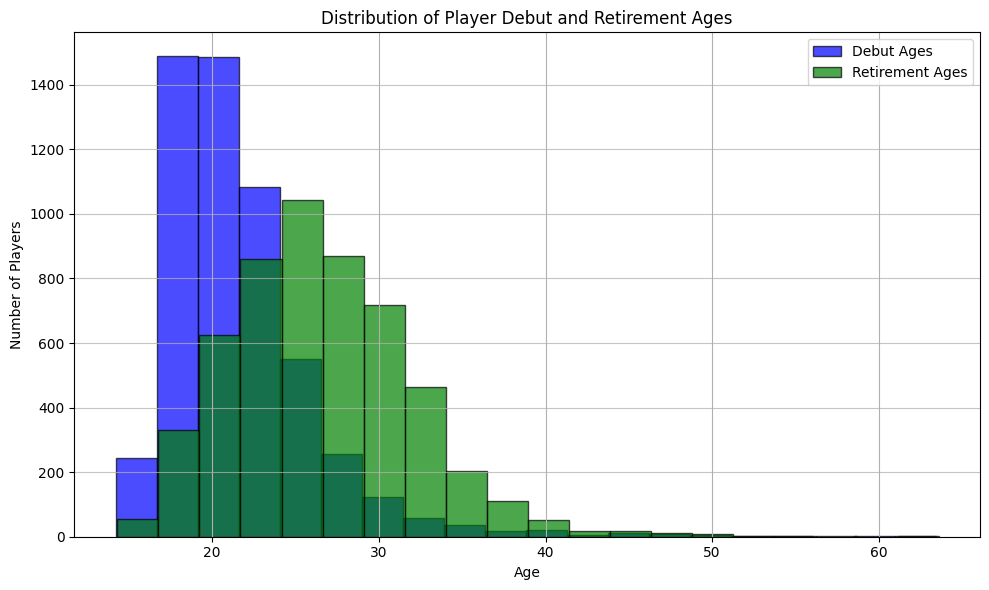

In [ ]:
plt.figure(figsize=(10, 6))
debut_ages.hist(bins=20, edgecolor='black', color='blue', alpha=0.7, label='Debut Ages')
retirement_ages.hist(bins=20, edgecolor='black', color='green', alpha=0.7, label='Retirement Ages')
plt.title('Distribution of Player Debut and Retirement Ages')
plt.xlabel('Age')
plt.ylabel('Number of Players')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

#### Does date of birth behave like it does in hockey for tennis? (Looking at Birthmonths of atp tennis players).

There is an intresting pattern in proffesional hockeyleagues, where there is a skew in birth months towards January. it's believed this is caused by the season opening for hockey late in the year, allowing for those born in januarry to grow in size more than those born later. Tennis does not seem to also have this trend, we see birthday's evenly spread out

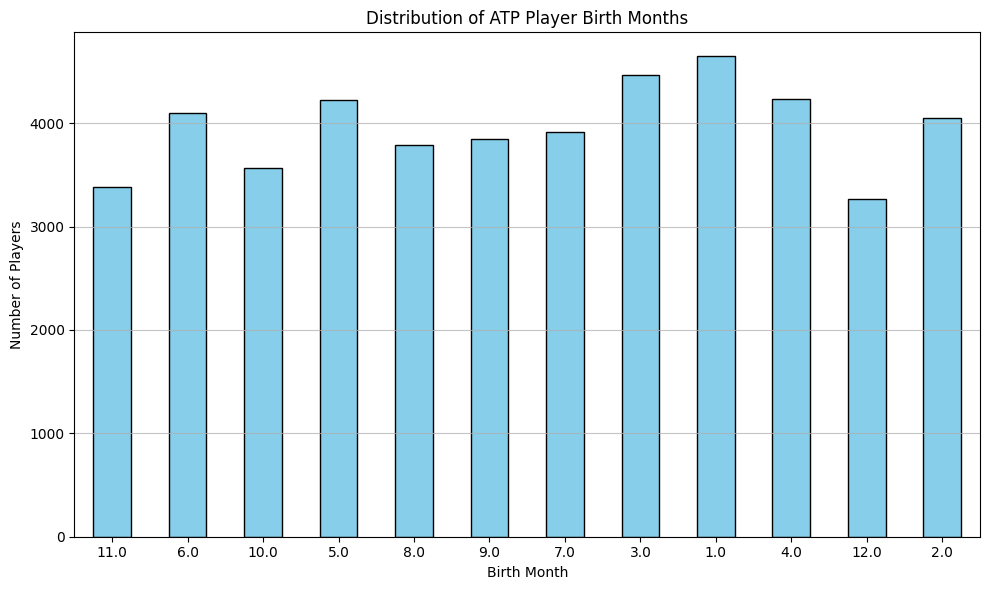

In [ ]:
# Clean and convert dob to datetime, handling potential errors
tennis_players['dob_cleaned'] = pd.to_numeric(tennis_players['dob'], errors='coerce')
tennis_players['dob_cleaned'] = tennis_players['dob_cleaned'].astype(str).str.split('.').str[0]
tennis_players['dob_cleaned'] = pd.to_datetime(tennis_players['dob_cleaned'], format='%Y%m%d', errors='coerce')

# Extract birth month
tennis_players['birth_month'] = tennis_players['dob_cleaned'].dt.month

# Plot the distribution of birth months
plt.figure(figsize=(10, 6))
tennis_players['birth_month'].value_counts(sort=False).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of ATP Player Birth Months')
plt.xlabel('Birth Month')
plt.ylabel('Number of Players')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

#### Do certain countries produce more tennis players than others?

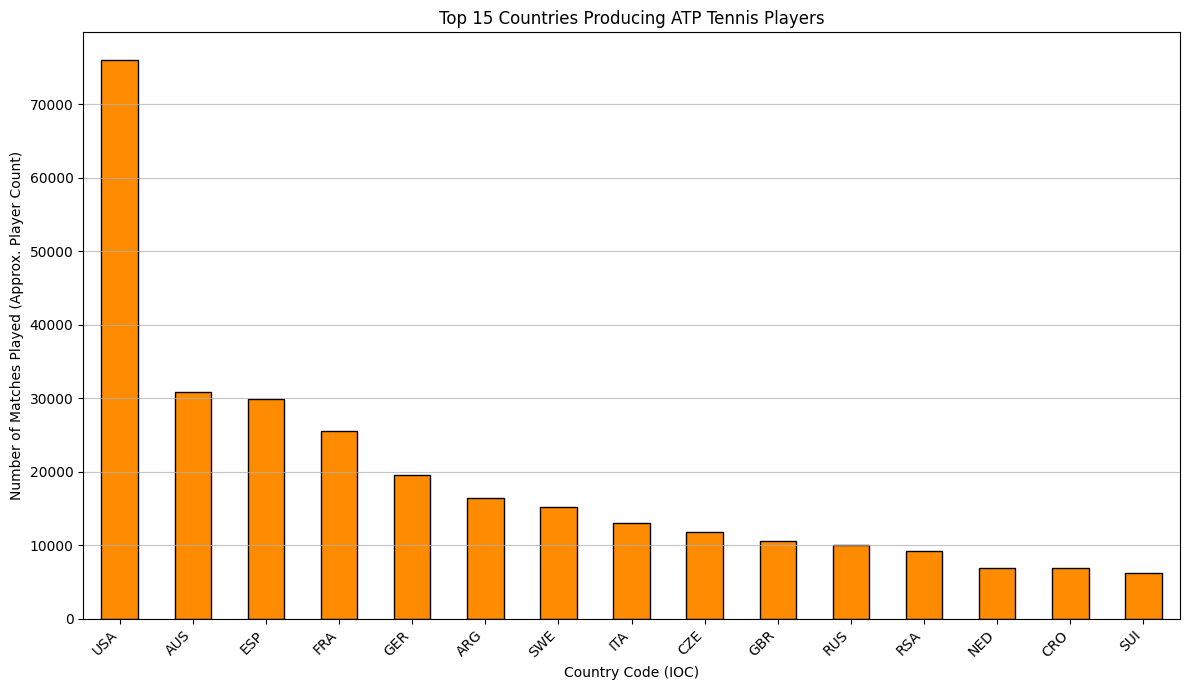

In [ ]:
all_countries = pd.concat([tennis_matches['winner_ioc'], tennis_matches['loser_ioc']])

country_counts = all_countries.value_counts()
top_n=15

plt.figure(figsize=(12, 7))
country_counts.head(top_n).plot(kind='bar', color='darkorange', edgecolor='black')
plt.title(f'Top {top_n} Countries Producing ATP Tennis Players')
plt.xlabel('Country Code (IOC)')
plt.ylabel('Number of Matches Played (Approx. Player Count)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## Train Test Split

we can treat everything before 2023 as a training set, making all matches in 2024 a test set.

We also need to be sure that we remove the target player1_won column that tells us who won

In [ ]:
# Extract the year from tourney_id for splitting
true_matches['year'] = true_matches['tourney_id'].str[:4].astype(int)

# Define the target variable
y = true_matches['player1_won']

# Drop columns that should not be part of the features, including the target and 'elo_after' columns (already dropped), and identifiers
features_df = true_matches.drop(columns=['game_id', 'tourney_id', 'year', 'player1_won'])

# Split data into training and test sets based on the year
X_train = features_df[true_matches['year'] < 2024]
y_train = y[true_matches['year'] < 2024]
X_test = features_df[true_matches['year'] >= 2024]
y_test = y[true_matches['year'] >= 2024]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

display(X_train.head())
display(X_train.tail())

Shape of X_train: (191920, 20)
Shape of y_train: (191920,)
Shape of X_test: (3076, 20)
Shape of y_test: (3076,)


,surface,tourney_level,draw_size,match_num,player1_id,player2_id,player1_elo_before,player2_elo_before,player1_age,player1_hand,player1_rank,player1_rank_points,player1_ioc,player1_ht,player2_age,player2_hand,player2_rank,player2_rank_points,player2_ioc,player2_ht
0,Clay,A,NaN,101,100092,100113,1500.0,1500.0,23.100000,R,NaN,NaN,RUS,NaN,21.799999,R,NaN,NaN,CZE,175.0
1,NaN,A,NaN,101,100035,100141,1500.0,1500.0,28.600000,R,NaN,NaN,ROU,185.0,20.500000,R,NaN,NaN,CRO,NaN
2,Clay,A,NaN,102,100070,110991,1500.0,1500.0,25.200001,R,NaN,NaN,CZE,NaN,25.600000,R,NaN,NaN,IND,NaN
3,NaN,A,NaN,102,211821,100051,1500.0,1500.0,NaN,U,NaN,NaN,IND,NaN,27.100000,R,NaN,NaN,IND,NaN
4,Clay,A,NaN,103,100119,100051,1500.0,1516.0,21.400000,R,NaN,NaN,ROU,183.0,27.100000,R,NaN,NaN,IND,NaN


,surface,tourney_level,draw_size,match_num,player1_id,player2_id,player1_elo_before,player2_elo_before,player1_age,player1_hand,player1_rank,player1_rank_points,player1_ioc,player1_ht,player2_age,player2_hand,player2_rank,player2_rank_points,player2_ioc,player2_ht
191915,Hard,F,8.0,296,207925,209950,1529.706771,1682.162165,21.500000,R,100.0,640.0,ITA,183.0,19.400000,R,36.0,1158.0,FRA,185.0
191916,Hard,F,8.0,297,208502,209950,1654.353102,1691.559751,21.200001,L,94.0,673.0,SUI,183.0,19.400000,R,36.0,1158.0,FRA,185.0
191917,Hard,F,8.0,298,209098,208502,1591.978601,1640.060011,20.299999,R,110.0,582.0,SRB,188.0,21.200001,L,94.0,673.0,SUI,183.0
191918,Hard,F,8.0,299,209414,209950,1563.090584,1705.852842,19.500000,R,70.0,756.0,FRA,178.0,19.400000,R,36.0,1158.0,FRA,185.0
191919,Hard,F,8.0,300,209098,209950,1610.178804,1715.625018,20.299999,R,110.0,582.0,SRB,188.0,19.400000,R,36.0,1158.0,FRA,185.0


## Training Model

In [ ]:
print(xgb.__version__)
print(xgb.build_info())

3.1.2
{'BUILTIN_PREFETCH_PRESENT': True, 'CUDA_VERSION': [12, 8], 'DEBUG': False, 'GCC_VERSION': [10, 3, 1], 'GLIBC_VERSION': [2, 28], 'MM_PREFETCH_PRESENT': True, 'NCCL_VERSION': [2, 27, 7], 'THRUST_VERSION': [2, 7, 0], 'USE_CUDA': True, 'USE_DLOPEN_NCCL': True, 'USE_FEDERATED': True, 'USE_NCCL': True, 'USE_NVCOMP': False, 'USE_OPENMP': True, 'USE_RMM': False, 'libxgboost': '/usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so'}


In [ ]:
param_dist = {
    "n_estimators": randint(100, 301),
    "max_depth": randint(3, 8),
    "learning_rate": uniform(0.01, 0.19),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3)}

In [ ]:
X_train = X_train.copy()
X_test = X_test.copy()
y_train = y_train.copy()
y_test = y_test.copy()

categorical_cols = [
    'surface', 'tourney_level',
    'player1_hand', 'player1_ioc',
    'player2_hand', 'player2_ioc'
]

for col in categorical_cols:
    if col in features_df.columns:
        # Collect all unique categories from the full dataset (features_df) for consistency
        all_categories = features_df[col].astype('category').cat.categories

        # Apply CategoricalDtype to both X_train and X_test using the comprehensive categories
        X_train[col] = X_train[col].astype(pd.CategoricalDtype(categories=all_categories))
        X_test[col] = X_test[col].astype(pd.CategoricalDtype(categories=all_categories))

# Verification step to check for the 'O' category and types
print(f"Categories for 'tourney_level' in X_train: {X_train['tourney_level'].cat.categories.tolist()}")
print(f"Categories for 'tourney_level' in X_test: {X_test['tourney_level'].cat.categories.tolist()}")
print(f"Dtype of 'surface' in X_train: {X_train['surface'].dtype}")
print(f"Dtype of 'surface' in X_test: {X_test['surface'].dtype}")

if 'O' in X_train['tourney_level'].cat.categories:
    print("Category 'O' is present in X_train['tourney_level'] categories.")
else:
    print("Category 'O' is *NOT* present in X_train['tourney_level'] categories. This needs fixing before retraining.")

if 'O' in X_test['tourney_level'].cat.categories:
    print("Category 'O' is present in X_test['tourney_level'] categories.")
else:
    print("Category 'O' is *NOT* present in X_test['tourney_level'] categories.")


Categories for 'tourney_level' in X_train: ['A', 'D', 'F', 'G', 'M', 'O']
Categories for 'tourney_level' in X_test: ['A', 'D', 'F', 'G', 'M', 'O']
Dtype of 'surface' in X_train: category
Dtype of 'surface' in X_test: category
Category 'O' is present in X_train['tourney_level'] categories.
Category 'O' is present in X_test['tourney_level'] categories.


In [ ]:
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss", #or roc_auc
    tree_method="hist",
    predictor="gpu_predictor",
    enable_categorical=True,
    random_state=42
)
model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Define the model filename
model_filename = "xgb_best_model.pkl"

# Check if the model file already exists
if os.path.exists(model_filename):
    print(f"'{model_filename}' already exists. Skipping RandomizedSearchCV training.")
    # Load the existing model if it exists
    best_model = joblib.load(model_filename)
    random_search = None # Set random_search to None if skipping training
else:
    print(f"'{model_filename}' not found. Proceeding with RandomizedSearchCV training.")
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=10,
        scoring="neg_log_loss",
        cv=3,
        verbose=2,
        n_jobs=1,           # MUST be 1 for GPU
        random_state=42)

    print("\n--- Retraining model with updated categorical types ---")
    random_search.fit(X_train, y_train)

    print("Best params:", random_search.best_params_)
    print("Best score:", random_search.best_score_)

    # Save the best model only if training was performed
    best_model = random_search.best_estimator_
    joblib.dump(best_model, model_filename)


'xgb_best_model.pkl' not found. Proceeding with RandomizedSearchCV training.

--- Retraining model with updated categorical types ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:48:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.19063571821788408, max_depth=5, n_estimators=171, subsample=0.8795975452591109; total time=   5.5s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:48:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8123620356542087, learning_rate=0.19063571821788408, max_depth=5, n_estimators=171, subsample=0.8795975452591109; total time=   5.5s


...

[CV] END colsample_bytree=0.7692681476866446, learning_rate=0.05579483854494223, max_depth=6, n_estimators=298, subsample=0.8829989973347863; total time=  11.1s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:51:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7692681476866446, learning_rate=0.05579483854494223, max_depth=6, n_estimators=298, subsample=0.8829989973347863; total time=  11.7s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:51:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'colsample_bytree': np.float64(0.7468055921327309), 'learning_rate': np.float64(0.039638958863878505), 'max_depth': 5, 'n_estimators': 187, 'subsample': np.float64(0.8001125833417065)}
Best score: -0.5900397499247396


Saving model

In [ ]:

# Ensure random_search has been run to get best_estimator_
best_model = random_search.best_estimator_
model_filename = "xgb_best_model.pkl"

# Save to file only if it does not exist
if not os.path.exists(model_filename):
    print(f"'{model_filename}' not found. Saving the newly trained model.")
    joblib.dump(best_model, model_filename)
else:
    print(f"'{model_filename}' already exists. Skipping save of current model.")

# Load the model
loaded_model = joblib.load(model_filename)


'xgb_best_model.pkl' already exists. Skipping save of current model.


In [ ]:
loaded_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.7468055921327309), device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None,
              learning_rate=np.float64(0.039638958863878505), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=187, n_jobs=None,
              num_parallel_tree=None, ...)

## Predicting

In [ ]:
yhat = loaded_model.predict(X_test)
yhat_proba = loaded_model.predict_proba(X_test)
print(yhat)
print(yhat_proba)

[1 1 1 ... 0 1 1]
[[0.45506305 0.54493695]
 [0.4376349  0.5623651 ]
 [0.48213148 0.5178685 ]
 ...
 [0.6632287  0.3367713 ]
 [0.4986987  0.5013013 ]
 [0.47029483 0.52970517]]


In [ ]:
print(yhat_proba)
# Convert probabilities to binary predictions (0 or 1)
yhat_binary = (yhat_proba[:, 1] >= 0.5).astype(int)
print(yhat_binary)

[[0.45506305 0.54493695]
 [0.4376349  0.5623651 ]
 [0.48213148 0.5178685 ]
 ...
 [0.6632287  0.3367713 ]
 [0.4986987  0.5013013 ]
 [0.47029483 0.52970517]]
[1 1 1 ... 0 1 1]


## Evaluating

In [ ]:
# Calculate metrics
accuracy = accuracy_score(y_test, yhat_binary)
precision = precision_score(y_test, yhat_binary)
recall = recall_score(y_test, yhat_binary)
f1 = f1_score(y_test, yhat_binary)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.6414
Precision: 0.6337
Recall: 0.6614
F1-Score: 0.6473


The model appears to be correct 63% of the time, there is still plenty of room for imporvement however. (accuracy)

the model predicts 64% of positive cases (meaning player 1 to win) correctly. (precision)

of all actually positive instances, meaning games where player 1 actually win, our model predicted those 63.9 percent of time time correctly. (recall)

finally our model has a fairly good balance between guessing correctly true positive scores without over doing it (f1 score)

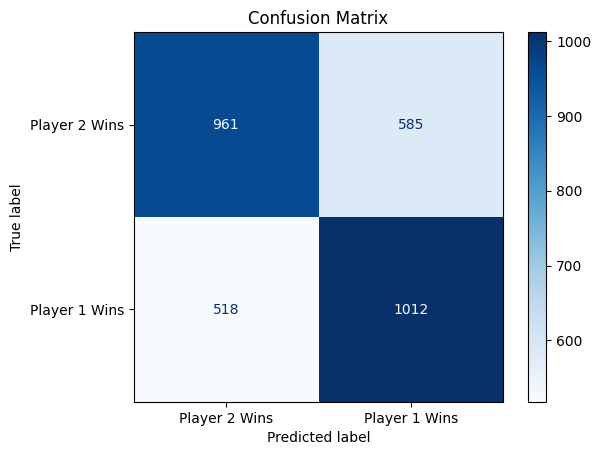

In [ ]:
# Compute the confusion matrix

cm = confusion_matrix(y_test, yhat_binary)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Player 2 Wins', 'Player 1 Wins'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()



Top 10 Most Important Features:


,Feature,Importance
6,player1_elo_before,0.183714
7,player2_elo_before,0.166974
10,player1_rank,0.097192
16,player2_rank,0.078759
9,player1_hand,0.078758
15,player2_hand,0.061864
19,player2_ht,0.056973
13,player1_ht,0.051403
4,player1_id,0.035538
5,player2_id,0.034408


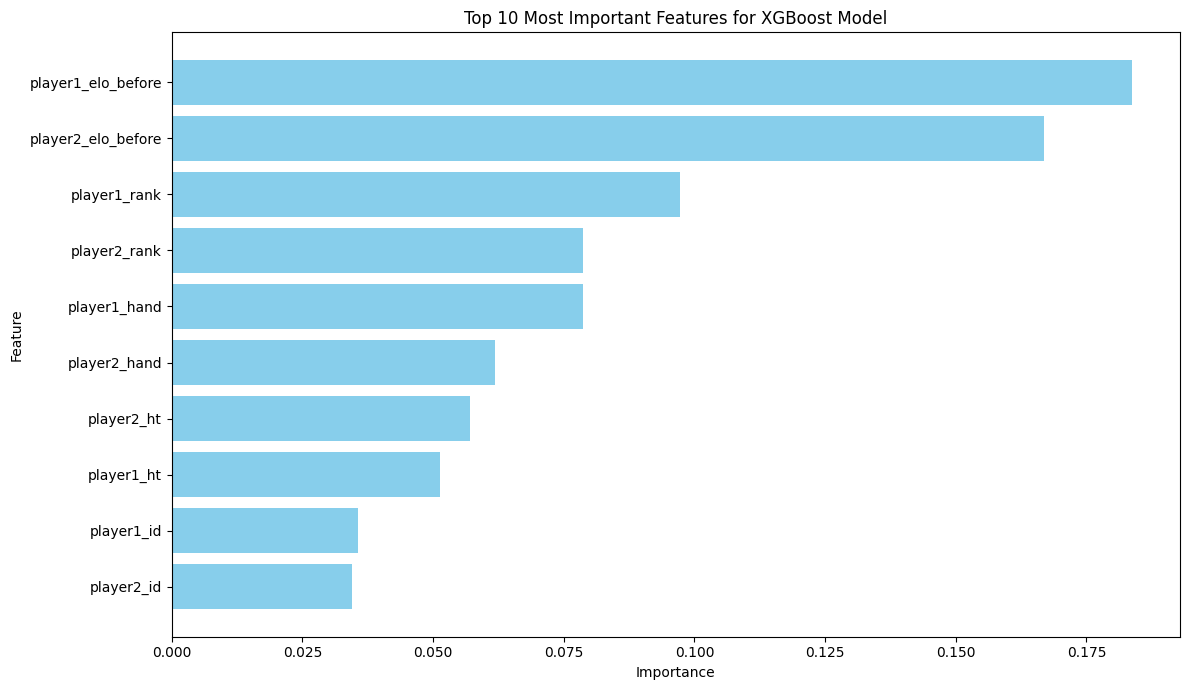

In [ ]:
feature_importances = loaded_model.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

num_top_features = 10
print(f"\nTop {num_top_features} Most Important Features:")
display(importance_df.head(num_top_features))

plt.figure(figsize=(12, 7))
plt.barh(importance_df['Feature'].head(num_top_features), importance_df['Importance'].head(num_top_features), color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Features for XGBoost Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
